In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt

import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [5]:
index_min = 100
index_max = 300

E = data['E'][index_min:index_max]
Q = data['q'][index_min:index_max]
T = data['t'][index_min:index_max]

In [6]:
from skimage.restoration import unwrap_phase

In [7]:
phases = np.stack([unwrap_phase(np.angle(E[i])) for i in range(E.shape[0])])

In [8]:
# Pad  with zeros to make it square
max_size = max(phases.shape[1], phases.shape[2])
diff_size = np.abs(phases.shape[1] - phases.shape[2])
if phases.shape[2] < phases.shape[1]:
    phases = np.pad(phases, ((0, 0), (0, 0), (diff_size // 2, diff_size // 2)), mode='constant')
    E = np.pad(E, ((0, 0), (0, 0), (diff_size // 2, diff_size // 2)), mode='constant')
else:
    phases = np.pad(phases, ((0, 0), (diff_size // 2, diff_size // 2), (0, 0)), mode='constant')
    E = np.pad(E, ((0, 0), (diff_size // 2, diff_size // 2), (0, 0)), mode='constant')

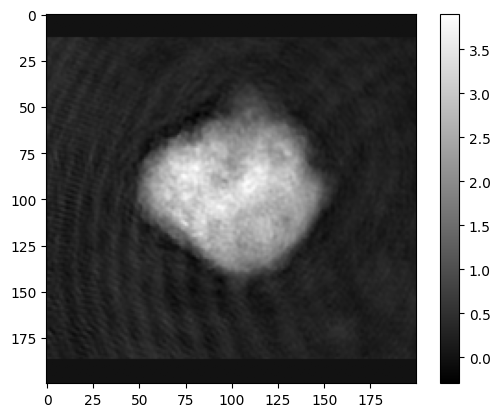

In [9]:
plt.imshow(phases[0], cmap='gray')
plt.colorbar()

In [10]:
E_upd = E.copy()

In [11]:
def correctfield(field, n_iter=5):
    """
    Correct field
    """

    if field.dtype == torch.float32:
        field = field.to(torch.complex64)

    f_new = field.clone()

    # Normalize with mean of absolute value.
    f_new = f_new / torch.mean(torch.abs(f_new))

    for _ in range(n_iter):
        f_new = f_new * torch.exp(-1j * torch.median(torch.angle(f_new)))

    return f_new

In [12]:
E = correctfield(torch.tensor(E_upd, device=DEV, dtype=torch.complex64), n_iter=5).cpu().numpy()

In [13]:
E_upd = E.copy()
th = 0.56
for i in range(E_upd.shape[0]):
    tmp = phases[i]
    
    # Set values below threshold to 1
    mask = tmp < th


    real_part = np.real(E_upd[i])
    imag_part = np.imag(E_upd[i])

    # Combine real and imaginary parts back into a complex field
    E_upd[i] = real_part + 1j * imag_part

    # Set values below threshold to 1
    E_upd[i][mask] = 1 

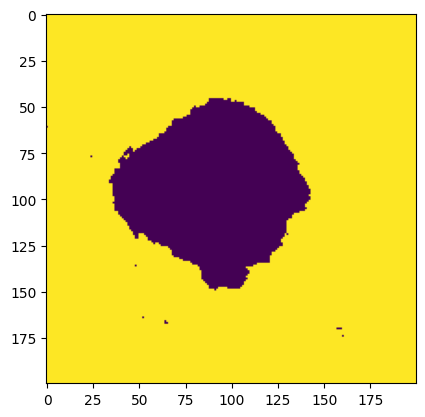

In [14]:
plt.imshow(mask)

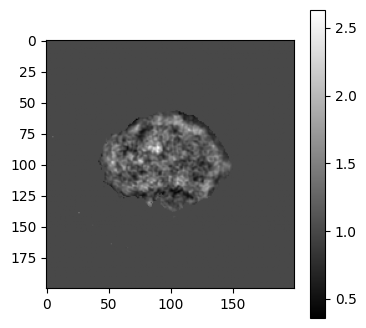

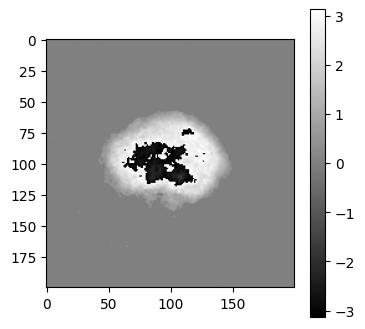

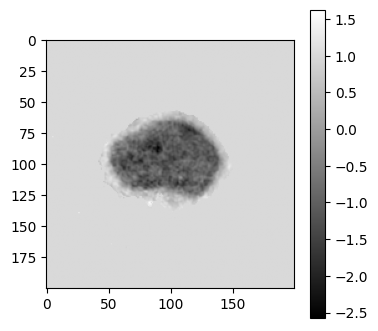

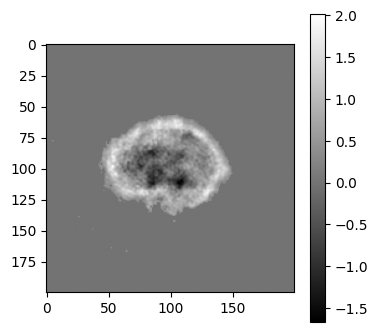

In [15]:
plt.figure(figsize=(4, 4))
plt.imshow(np.abs(E_upd[70]), cmap='gray')
plt.colorbar()
plt.figure(figsize=(4, 4))
plt.imshow(np.angle(E_upd[70]), cmap='gray')
plt.colorbar()
plt.figure(figsize=(4, 4))
plt.imshow(np.real(E_upd[70]), cmap='gray')
plt.colorbar()
plt.figure(figsize=(4, 4))
plt.imshow(np.imag(E_upd[70]), cmap='gray')
plt.colorbar()

In [16]:
E = E_upd

In [17]:
N = 144

In [18]:
pad_x, pad_y = (E.shape[1]- N) // 2, (E.shape[2] - N) // 2
E = E[:, pad_x:pad_x + N, pad_y:pad_y + N]

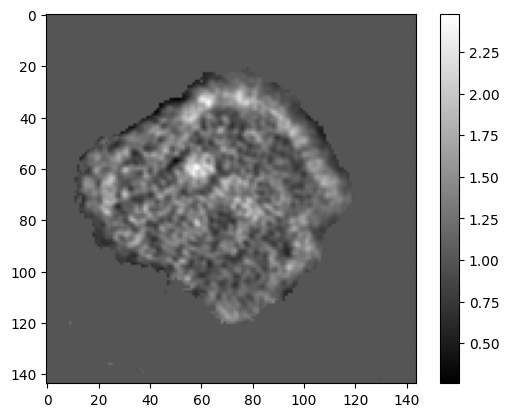

In [19]:
plt.imshow(np.abs(E[80]), cmap='gray')
plt.colorbar()

In [20]:
E.shape

(200, 144, 144)

In [21]:
# Make 2 channels for imag and real part
E = np.stack([np.real(E), np.imag(E)], axis=1)

In [22]:
E.shape

(200, 2, 144, 144)

In [23]:
np.min(np.abs(E))

0.0

In [24]:

# Mean downsampled volume with skimage
from skimage.measure import block_reduce

E = np.array([block_reduce(e, (1, 2, 2), np.mean) for e in E])

In [25]:
N = E.shape[-1]

In [26]:
E.shape

(200, 2, 72, 72)

In [27]:
projections = torch.tensor(E, dtype=torch.float32).to(DEV)

In [28]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# Setup the optics
optics_setttings = setup_optics(
        nsize=N, 
        padding_xy=N//2, 
        microscopy_regime='Brightfield', 
        NA=1.15, 
        wavelength=640e-9, 
        resolution=400e-9, 
        magnification=1, 
        return_field=True)

# Generate the imaging model
brightfield_model = imaging_model(optics_setup=optics_setttings)

In [29]:
q_new = Q.copy()

q_new[...,1] = Q[...,2]
q_new[...,2] = Q[...,3]
q_new[...,3] = Q[...,1]


In [30]:
t_new = T.copy()
t_new[..., 0] = T[...,0] #0
t_new[..., 1] = T[..., 2]
t_new[..., 2] = T[..., 1]

# Downsample translations and convert to pixels
t_new = t_new / 2 / 2e-7

In [31]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=(N, N, N), # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model,
    )

In [32]:
# Initialize the parameters
tomographic_model.initialize_parameters(projections, normalize=False, initial_frames_per_rotation=150, max_epochs=500)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name                | Type                 | Params | Mode 
---------------------------------------------------------------------
0 | encoder             | Sequential           | 80.1 K | train
1 | fc_mu               | MultiLayerPerceptron | 41.5 K

Epoch 499: 100%|██████████| 7/7 [00:00<00:00, 59.91it/s, v_num=1100, train_rec_loss_step=0.0503, train_KL_step=60.00, train_total_loss_step=0.0509, train_rec_loss_epoch=0.0518, train_KL_epoch=234.0, train_total_loss_epoch=0.0541]  


For vizualisation we initialize a `TomoPlotter` class.

In [33]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)


Using the VAE, we can visualize the **latent space** over time, revealing a trajectory that captures the system’s dynamics. Notably, **rotational movements** appear as transitions in this space, showing how the model encodes changes in orientation.


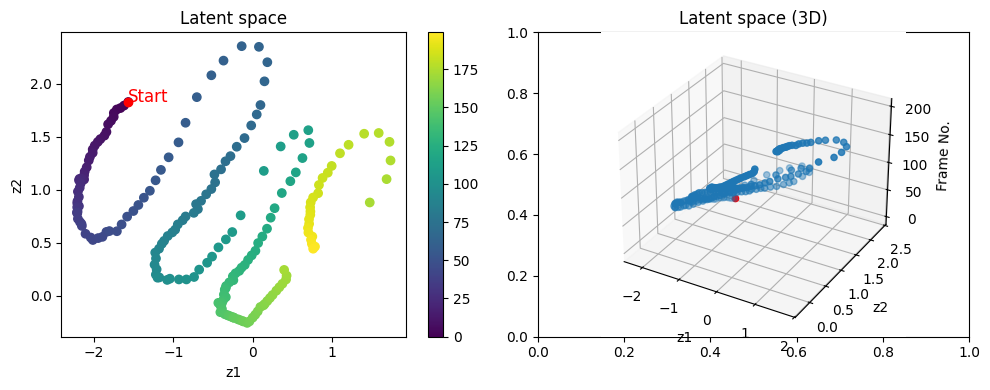

In [34]:
plotter.plot_latent_space()

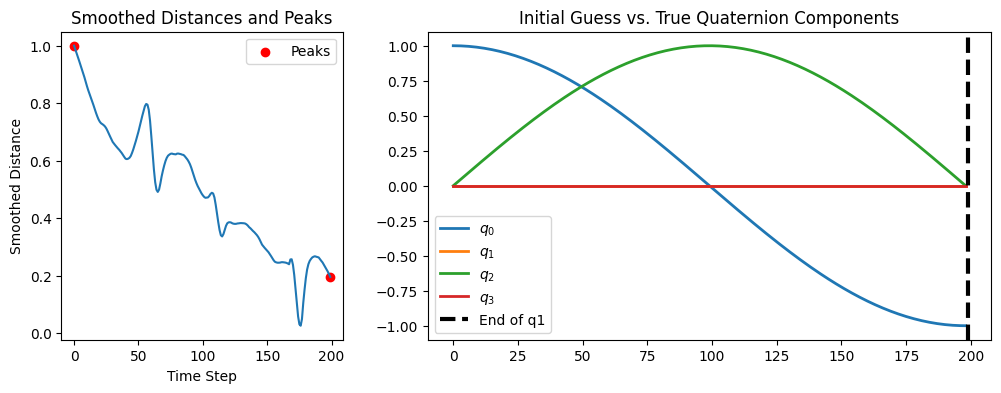

In [35]:
plotter.plot_smooth_dist_intial_guess()

To further validate the VAE, we compare reconstructed frames to the originals and observe a strong visual similarity.

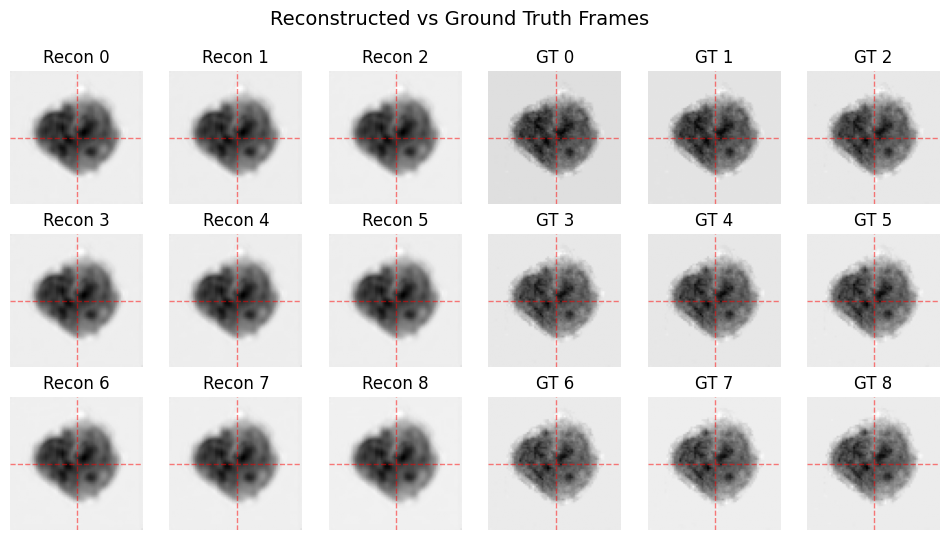

In [36]:
plotter.plot_reconstructed_vs_gt()

In [89]:
vol_gt = data['n']

In [90]:
vol_gt = vol_gt[:, 12:-12, 25:-25]

In [91]:
vol_gt = vol_gt[3:-3, 3:-3, 3:-3]

In [92]:
vol_gt.shape

(144, 144, 144)

In [93]:
#vol_gt = vol_gt[11:-11, 11:-11, 11:-11]

In [94]:
vol_gt = np.moveaxis(vol_gt, 0, -1)  # Move the first axis to the last position

In [95]:
# Downsample the volume with skimage

vol_gt = np.array([block_reduce(vol_gt, (2, 2, 2), np.mean)])[0] - 1.33

In [96]:
tomographic_model.rotation_params = torch.nn.Parameter(torch.tensor(q_new[:len(tomographic_model.rotation_params)]))
tomographic_model.translation_params = torch.nn.Parameter(torch.tensor(t_new[:len(tomographic_model.translation_params)]))

# 
tomographic_model.volume = torch.nn.Parameter(torch.tensor(vol_gt).to(DEV))

### 3.3 - Optimize the volume alone first

As outline in the main section, it is now time to proceede with the actual 3D-reconstruction optimization.

The optimization process flows more effectively when an initial 3D volume is optimized first. To achieve this, the volume is optimized for a few iterations before both the volume and rotation parameters are jointly optimized. While it is possible to provide a custom initial volume to begin the optimization, in this case, we start with a fixed volume value of 1.33.

In [97]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # Index of frames
epochs_object_only = 100 # Number of epochs for the object only optimization
batch_size_object_only = 16 # Batch size for the object only optimization

train the model for `epochs_object_only` epochs...

In [98]:
#tomographic_model.volume = nn.Parameter(torch.tensor(volume, dtype=torch.float32).to(DEV)-1.33)

In [99]:
# Move the model to device
tomographic_model.move_all_to_device(DEV)

tomographic_model.toggle_gradients_quaternion(False)
tomographic_model.toggle_gradients_translation(False)

# Number of iterations for the training loop
it = epochs_object_only 

trainer = dl.Trainer(max_epochs=it, accelerator="auto", enable_model_summary=False)

start_time = time.time()
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only, shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")



c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (13) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0:   0%|          | 0/13 [00:00<?, ?it/s] 

Epoch 28:  62%|██████▏   | 8/13 [00:02<00:01,  3.15it/s, v_num=1102, train_total_loss_step=2.060, train_proj_loss_step=2.000, train_latent_loss_step=0.0148, train_rtv_loss_step=0.00292, train_so_loss_step=0.0419, train_total_loss_epoch=2.070, train_proj_loss_epoch=2.000, train_latent_loss_epoch=0.0207, train_rtv_loss_epoch=0.00294, train_so_loss_epoch=0.0427] 

NameError: name 'exit' is not defined

(<Figure size 1500x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'Total loss'}, xlabel='Step'>,
         <Axes: title={'center': 'Proj loss'}, xlabel='Step'>,
         <Axes: title={'center': 'Latent loss'}, xlabel='Step'>],
        [<Axes: title={'center': 'Rtv loss'}, xlabel='Step'>,
         <Axes: title={'center': 'So loss'}, xlabel='Step'>, <Axes: >]],
       dtype=object))

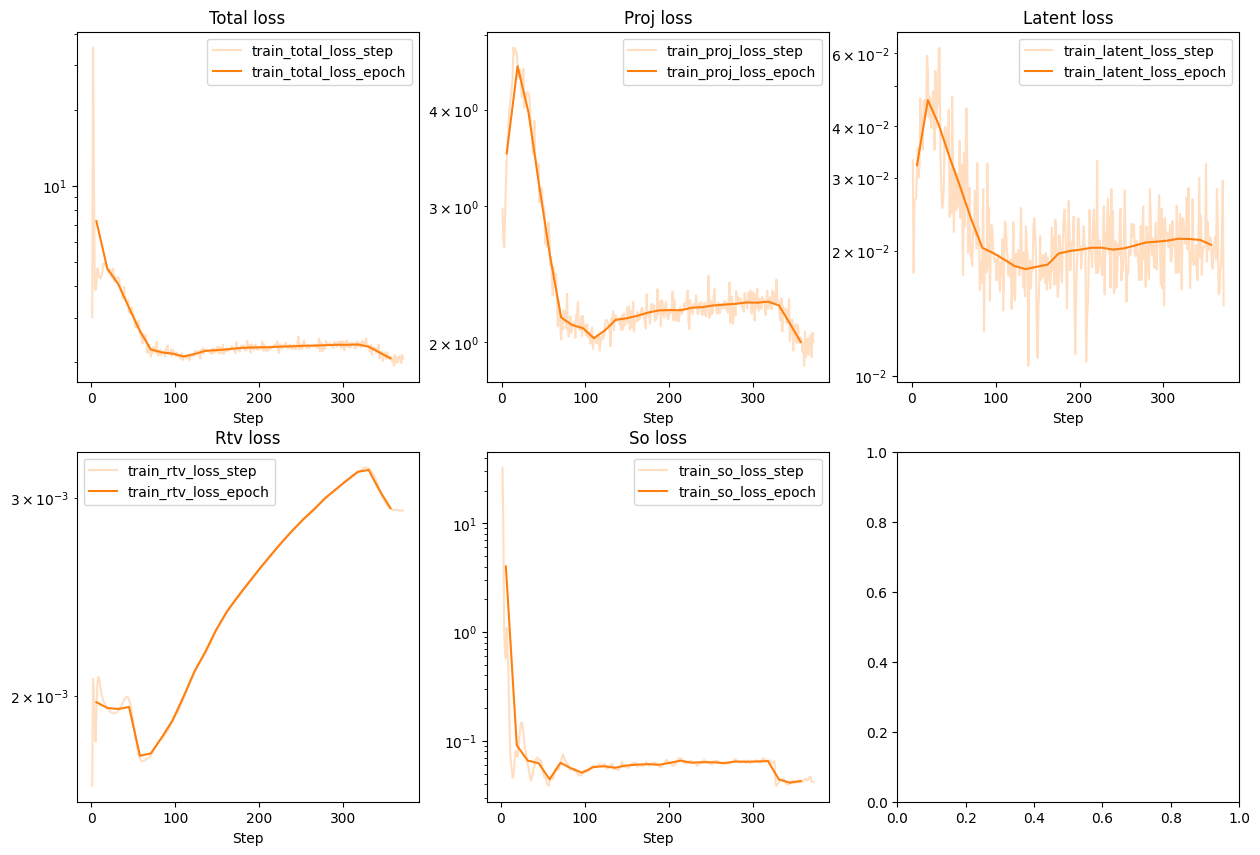

In [100]:
trainer.history.plot()

## 4.0 - Visualize the reconstructed volume and the parameters

Finally, we visualize the reconstructed 3D volume and the rotation parameters. The reconstructed volume is displayed as a 3D volume, while the rotation parameters are represented in a 3D scatter plot.

In [101]:
# Clear the GPU memory
torch.cuda.empty_cache()

In [102]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

By visualizing summation views of the 3D object along the x, y, and z axes, we can assess how well the optimized volume matches the ground truth.

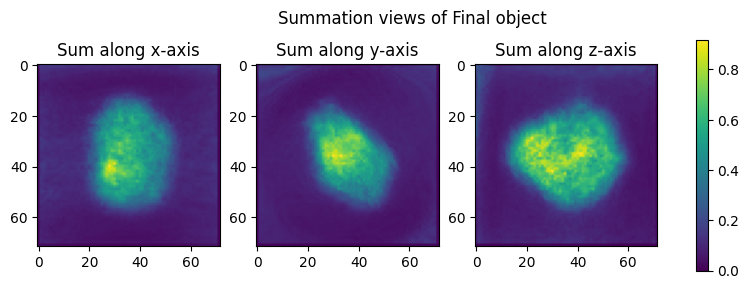

In [103]:
plotter.plot_sum_object(save_name="Final object")

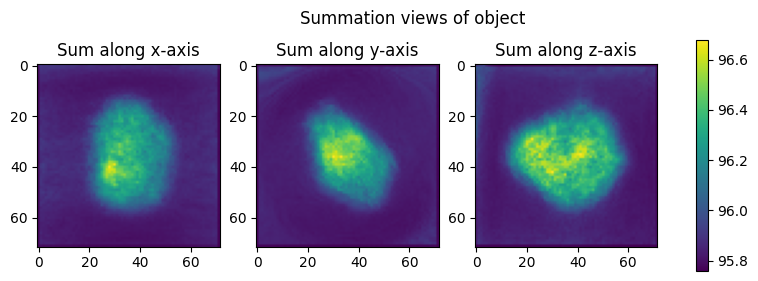

In [104]:
vol = tomographic_model.volume.cpu().detach().numpy()
tomodpdt.plotting.plot_sum_object(vol+1.33)


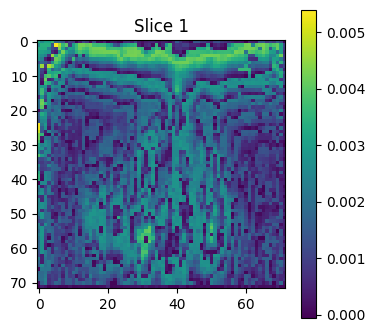

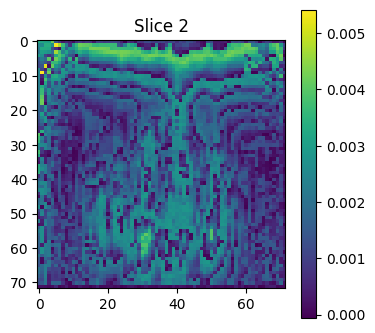

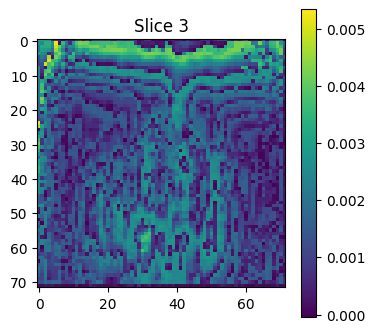

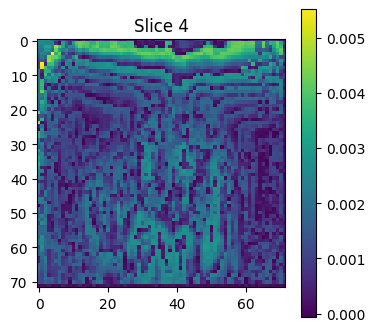

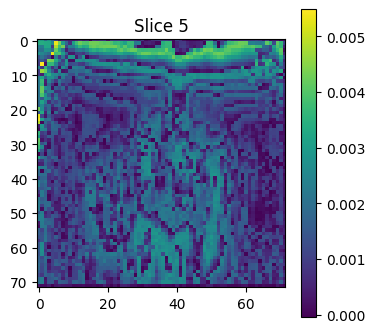

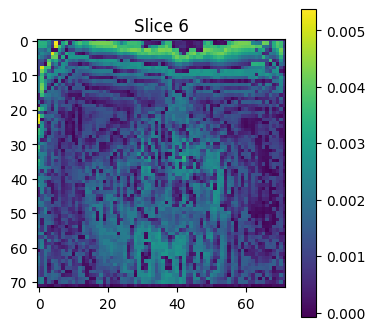

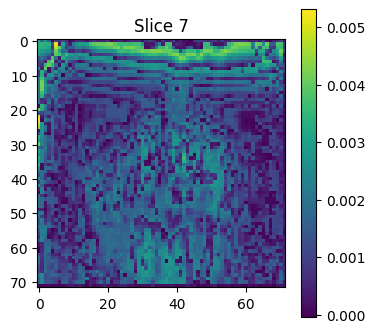

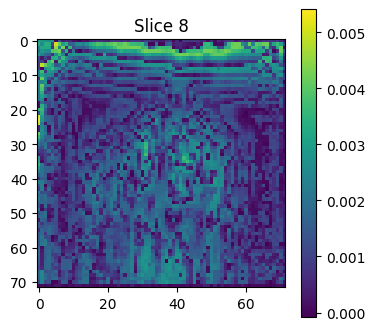

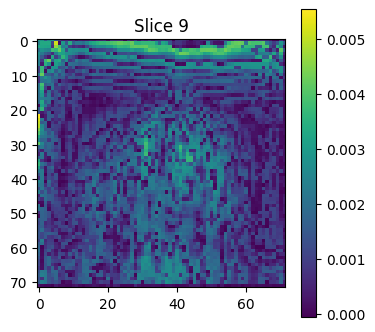

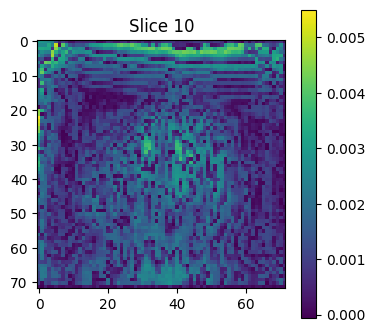

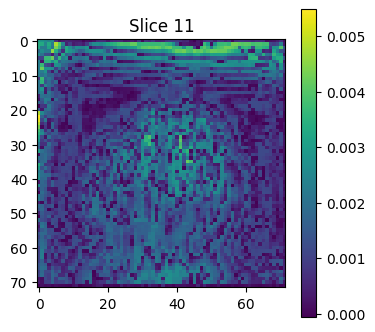

In [105]:
count=0
for i in range(0, vol.shape[0]):
    if np.max(vol[:, :, i]) < 0.005:
        continue
    else:
        count += 1
    plt.figure(figsize=(4, 4))
    plt.imshow(vol[:, :, i])
    plt.colorbar()
    plt.title(f'Slice {i}')
    plt.show()

    if count > 10:
        break


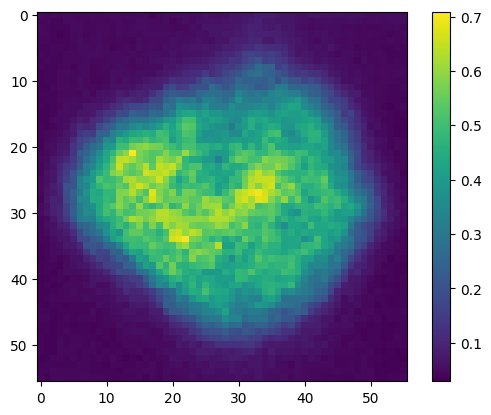

In [106]:
crop = 8
plt.imshow(tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop].detach().cpu().sum(2))
plt.colorbar()

In [107]:
# tomodpdt.plotting.visualize_3d_volume(
#    tomographic_model.volume.cpu().detach().numpy(), 
# )

Instead of summation views, we can visualize the forward projections of the reconstructed object and compare them to the ground truth 2D frames. The similarity indicates a successful reconstruction.

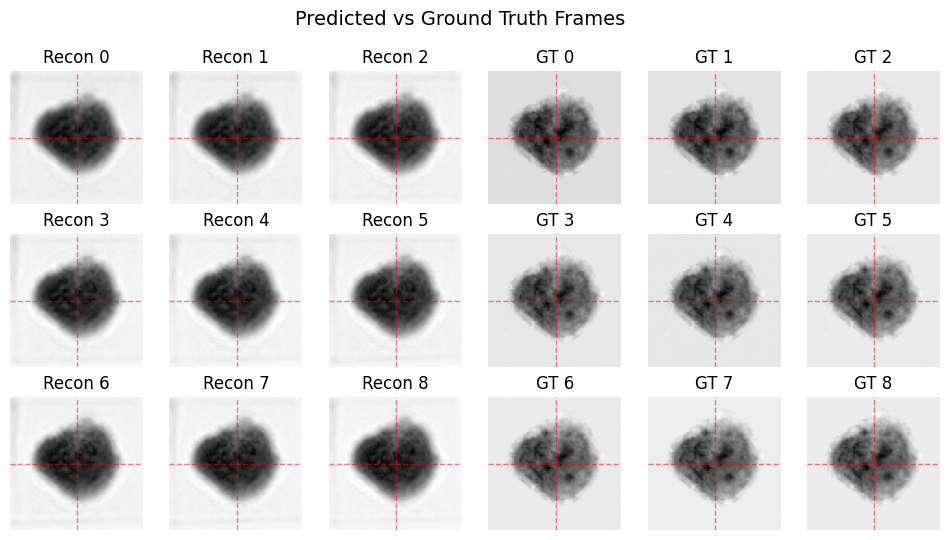

In [108]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

In [109]:
qq = torch.tensor(q_new).cpu().detach().numpy()

# Normalize so the first quaternion is [1, 0, 0, 0] and the rest are relative to it
qq = qq / np.linalg.norm(qq, axis=1, keepdims=True)

In [110]:
import torch

def quat_inverse(q):
    # q is (..., 4) quaternion
    w, x, y, z = q.unbind(-1)
    return torch.stack([w, -x, -y, -z], dim=-1) / q.norm(dim=-1, keepdim=True)**2

def quat_multiply(q1, q2):
    # Hamilton product
    w1, x1, y1, z1 = q1.unbind(-1)
    w2, x2, y2, z2 = q2.unbind(-1)
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return torch.stack([w, x, y, z], dim=-1)

quats = torch.tensor(qq, dtype=torch.float32)
q0_inv = quat_inverse(quats[0])
relative_quats = quat_multiply(q0_inv, quats)

In [111]:
qq_pred = tomographic_model.get_quaternions_final()
qq_pred = qq_pred.cpu().detach().numpy()

In [112]:
qq_init = tomographic_model.rotation_initial_dict['quaternions'].cpu().detach().numpy()

In [113]:
qq_init.shape

(199, 4)

In [114]:
tomographic_model.translation_params

Parameter containing:
tensor([[ 1.5534e+01,  2.7768e-01, -2.3900e+00],
        [ 1.5517e+01,  2.7389e-01, -2.3107e+00],
        [ 1.5541e+01,  2.4295e-01, -2.3395e+00],
        [ 1.5467e+01,  2.9056e-01, -2.2587e+00],
        [ 1.5460e+01,  2.7323e-01, -2.2516e+00],
        [ 1.5575e+01,  1.2417e-01, -2.4031e+00],
        [ 1.5643e+01,  2.1827e-01, -2.2256e+00],
        [ 1.5694e+01,  1.8027e-01, -2.2697e+00],
        [ 1.5727e+01, -1.6549e-02, -2.4261e+00],
        [ 1.5622e+01, -1.1405e-02, -2.4316e+00],
        [ 1.5726e+01,  2.4035e-02, -2.3661e+00],
        [ 1.5666e+01,  1.1426e-01, -2.3320e+00],
        [ 1.5734e+01,  1.2638e-01, -2.4190e+00],
        [ 1.5762e+01,  8.4816e-02, -2.4580e+00],
        [ 1.5651e+01,  9.7683e-02, -2.4136e+00],
        [ 1.5747e+01,  5.0659e-02, -2.5133e+00],
        [ 1.5922e+01, -1.7461e-03, -2.4876e+00],
        [ 1.6006e+01, -1.1948e-01, -2.4526e+00],
        [ 1.5968e+01, -1.4375e-01, -2.3629e+00],
        [ 1.5939e+01, -1.9404e-01, -2.3344e+00]

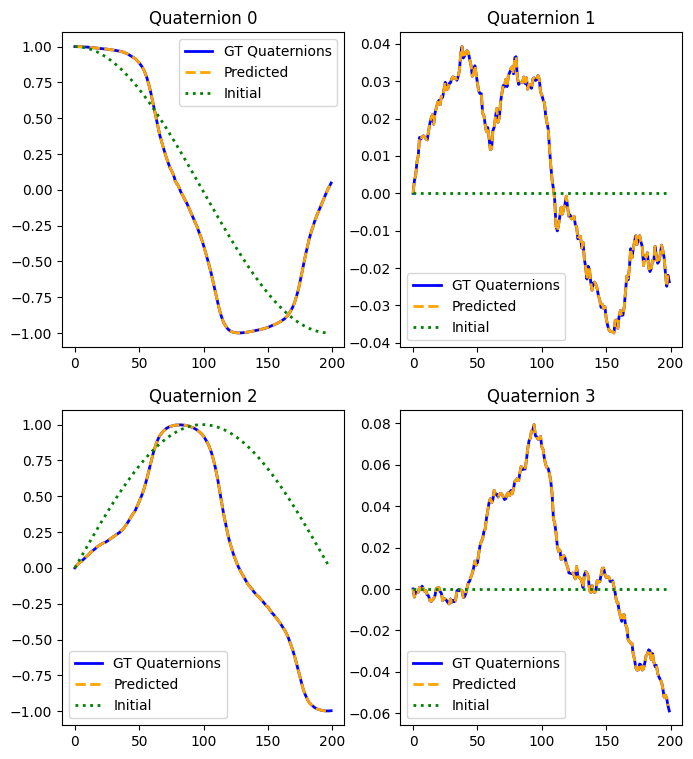

In [115]:
plt.figure(figsize=(8, 9))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.plot(relative_quats[:,i], label='GT Quaternions', linewidth=2, color='blue')
    plt.plot(qq_pred[:,i], label='Predicted', linestyle='--', linewidth=2, color='orange')
    plt.plot(qq_init[:,i], label='Initial', linestyle=':', linewidth=2, color='green')
    plt.title(f'Quaternion {i}')
    plt.legend()

In [116]:
idx = np.random.randint(0, len(tomographic_model.rotation_params), 10)

In [117]:
forward_projections = tomographic_model.full_forward_final(max_projections=10, idx=idx)

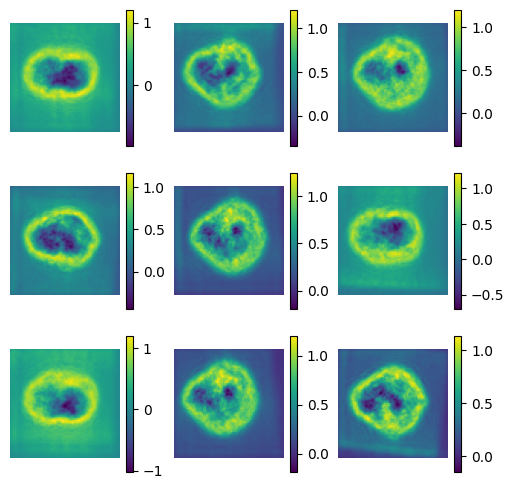

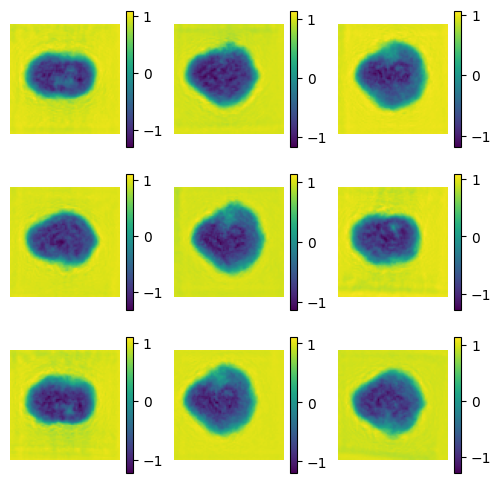

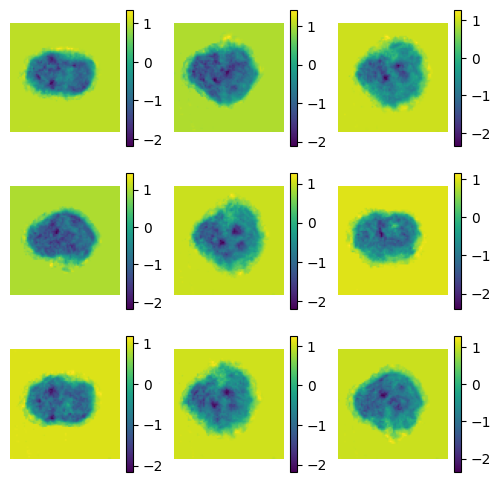

In [118]:
plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 1].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 0].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

# show projections
plt.figure(figsize=(6, 6))
for i, idx_ in enumerate(idx):
    if i >= 9:
        break
    proj_upd = tomographic_model.frames[idx_].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd[0])
    plt.colorbar()
    plt.axis('off')
plt.show()

Text(0.5, 0, 'Frame index')

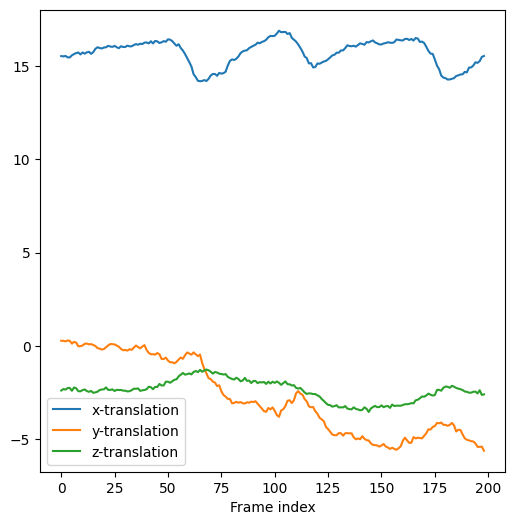

In [119]:
tt =  tomographic_model.get_translations_final()

plt.figure(figsize=(6, 6))
plt.plot(tt[:, 0].detach().cpu().numpy(), label='x-translation')
plt.plot(tt[:, 1].detach().cpu().numpy(), label='y-translation')
plt.plot(tt[:, 2].detach().cpu().numpy(), label='z-translation')
plt.legend()
plt.xlabel('Frame index')

In [120]:
qq = torch.tensor(qq, dtype=torch.float32, device=DEV)

In [121]:
tt[0]

tensor([15.5337,  0.2777, -2.3900], device='cuda:0', grad_fn=<SelectBackward0>)

In [122]:
qq[0]

tensor([-0.1593,  0.0334,  0.9864,  0.0220], device='cuda:0')

In [123]:
vol1 = tomographic_model.apply_rotation(tomographic_model.volume, q=qq[40], translations=tt[40])

In [124]:
vol2 =  tomographic_model.apply_rotation_batch(tomographic_model.volume, quaternions=qq[30:31], translations=tt[30:31])

In [125]:
#tomodpdt.plotting.visualize_3d_volume(vol2[0].detach().cpu().numpy()+1.33)

In [126]:
vol_gt = data['n']

In [127]:
# Pad y and z with zeros to make it square using np.pad 
# max_size = max(vol_gt.shape[1], vol_gt.shape[2])
# vol_gt = np.pad(vol_gt, ((0, 0), (0, max_size - vol_gt.shape[1]), (0, max_size - vol_gt.shape[2])), mode='constant', constant_values=0)

In [128]:
vol_gt = vol_gt[:, 12:-12, 25:-25]

In [129]:
vol_gt = vol_gt[3:-3, 3:-3, 3:-3]

In [130]:
vol_gt.shape

(144, 144, 144)

In [131]:
#vol_gt = vol_gt[11:-11, 11:-11, 11:-11]

In [132]:
vol_gt = np.moveaxis(vol_gt, 0, -1)  # Move the first axis to the last position

In [133]:
# Downsample the volume with skimage

vol_gt = np.array([block_reduce(vol_gt, (2, 2, 2), np.mean)])[0]

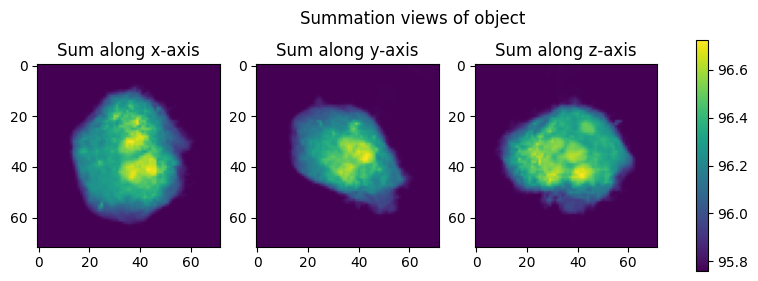

In [134]:
tomodpdt.plotting.plot_sum_object(vol_gt)

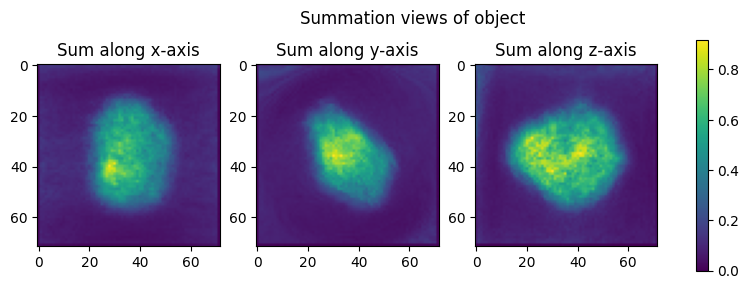

In [135]:
tomodpdt.plotting.plot_sum_object(vol)

In [136]:
#tomodpdt.plotting.visualize_3d_volume(vol_gt)

In [137]:
vol_gt = vol_gt - 1.33

In [138]:
tomographic_model.volume = nn.Parameter(torch.tensor(vol_gt, dtype=torch.float32).to(DEV))

In [139]:
idx =  np.random.randint(0, len(tomographic_model.frames), 10)

In [140]:
forward_projections = tomographic_model.full_forward_final(max_projections=10, idx=idx)

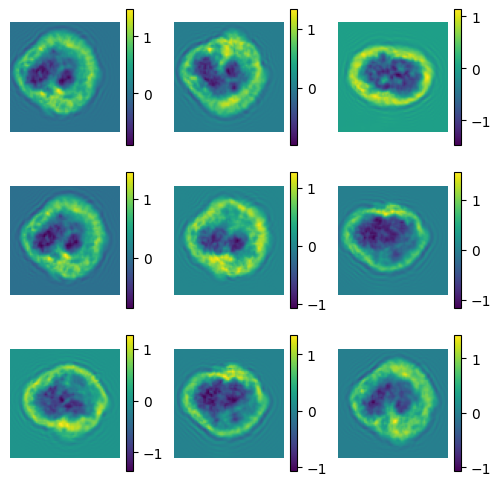

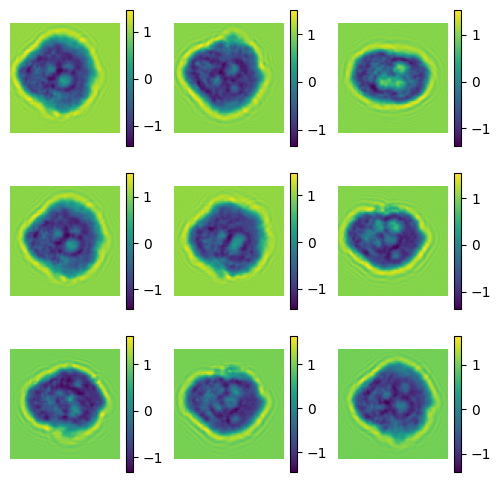

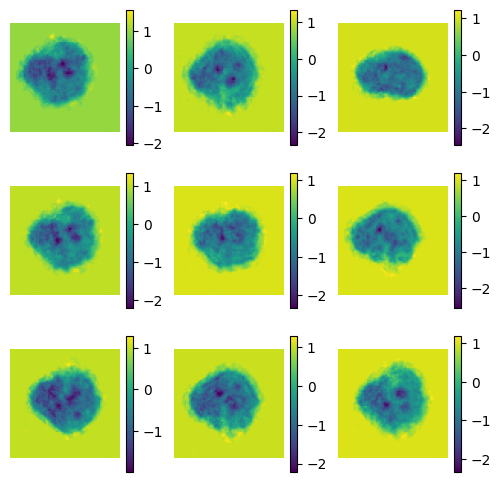

In [141]:
plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 1].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 0].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

# show projections
plt.figure(figsize=(6, 6))
for i, idx_ in enumerate(idx):
    if i >= 9:
        break
    proj_upd = tomographic_model.frames[idx_].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd[0])
    plt.colorbar()
    plt.axis('off')
plt.show()